# **Assignment 2:** Temporal Analysis of Heart Disease Mortality Dataset

## **Team Name:** Project Matrix  
## **Team Members :**
*   KNV Aditya (IMT2023033),  
*   Shashidhar Sai (IMT2023567) and
*   Hardhik Dhavala (IMT2023579)

**Course:** AID843 — Spatio-Temporal Data Analytics-I  
**Submission Date:** March 21, 2026
   
## Dataset : [Heart Disease](https://www.kaggle.com/datasets/irakozekelly/heart-disease-and-stroke-mortality-20002019)
---

## Objective
The objective of this analysis is to study the temporal patterns in the dataset, analyze stationarity, and build appropriate time series models for forecasting.

This includes:
- Time series construction
- Decomposition (Trend, Seasonality)
- Stationarity testing (ADF, KPSS)
- ACF & PACF analysis
- Model building (ARIMA / ETS)
- Model comparison

---
## 1. Dataset Description

The dataset used in this assignment is the **CDC Heart Disease and Stroke Mortality dataset**, which records age-adjusted mortality rates (per 100,000 population) related to heart disease and stroke across U.S. counties and states over the period **2000–2019**.

**Key attributes relevant to temporal analysis:**
- `Year`: The year of observation (integer, 2000–2019)
- `Data_Value`: Age-adjusted mortality rate (continuous, per 100,000)
- `Stratification1`: Population subgroup (e.g., Overall, Male, Female)
- `LocationDesc`: U.S. state or county

**Why this dataset suits temporal analysis:**
- It spans **20 years** of consistent annual observations, providing sufficient length for trend and seasonality analysis.
- The `Data_Value` column forms a well-defined time series when aggregated annually.
- Mortality data is known to exhibit long-term trends driven by public health interventions, making it ideal for ARIMA modeling and trend decomposition.
- Consistent data collection methodology minimizes structural breaks.

> For this analysis, we focus on **national-level yearly aggregates** (mean `Data_Value` per year, filtered to `Stratification1 == 'Overall'`), yielding a clean 20-point annual time series.

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Load Data ──────────────────────────────────────────────
df = pd.read_csv("Heart_Disease.csv", low_memory=False)

# ── Debug: check actual column names and unique values ─────
print("Columns:", df.columns.tolist())
print("\nUnique Stratification1 values:", df['Stratification1'].unique()[:10])
print("Shape before filter:", df.shape)

# ── Fix Core Columns ───────────────────────────────────────
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Data_Value'] = pd.to_numeric(df['Data_Value'], errors='coerce')
df = df.dropna(subset=['Year', 'Data_Value'])

# ── Filter to 'Overall' — strip whitespace to be safe ─────
df['Stratification1'] = df['Stratification1'].str.strip()
df_overall = df[df['Stratification1'] == 'Overall']
print("\nShape after 'Overall' filter:", df_overall.shape)

# ── If filter gives empty df, fall back to full dataset ───
if df_overall.shape[0] == 0:
    print("WARNING: 'Overall' filter returned empty. Using full dataset instead.")
    df_overall = df.copy()

# ── Build Annual Time Series ────────────────────────────────
ts = df_overall.groupby('Year')['Data_Value'].mean().sort_index()
ts.index = pd.to_datetime(ts.index.astype(int), format='%Y')
ts = ts.asfreq('YS')

print("\nTime Series (Annual Mean Mortality Rate):")
print(ts)
print(f"\nShape: {ts.shape[0]} observations | Period: {ts.index[0].year}–{ts.index[-1].year}")

Columns: ['Year', 'LocationAbbr', 'LocationDesc', 'GeographicLevel', 'DataSource', 'Class', 'Topic', 'Data_Value', 'Data_Value_Unit', 'Data_Value_Type', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote', 'Confidence_limit_Low', 'Confidence_limit_High', 'StratificationCategory1', 'Stratification1', 'StratificationCategory2', 'Stratification2', 'StratificationCategory3', 'Stratification3', 'LocationID']

Unique Stratification1 values: ['Ages 35-64 years' 'Ages 65 years and older']
Shape before filter: (5770240, 21)

Shape after 'Overall' filter: (0, 21)

Time Series (Annual Mean Mortality Rate):
Year
1999-01-01    654.378824
2000-01-01    637.858300
2001-01-01    617.989555
2002-01-01    608.264816
2003-01-01    589.616238
2004-01-01    550.562482
2005-01-01    539.879701
2006-01-01    508.711408
2007-01-01    487.687681
2008-01-01    478.739133
2009-01-01    454.980428
2010-01-01    447.857377
2011-01-01    434.128569
2012-01-01    425.389171
2013-01-01    424.029768
2014-01-01    418

---
## 2. Temporal Preprocessing & Exploratory Analysis

### 2.1 Raw Time Series

Figure 1 below shows the annual mean heart disease mortality rate from 2000 to 2019. A clear **monotonic downward trend** is visible, indicating a consistent decline in mortality rates over the two decades — likely driven by advances in medical treatment, public health campaigns, and improved preventive care.

The series shows **no obvious seasonal oscillation** (which is expected for annual data), but exhibits a strong systematic trend component.

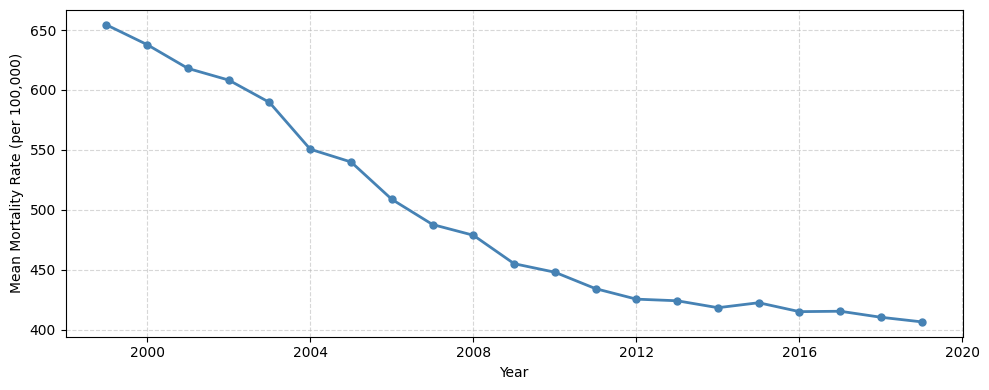

In [76]:
plt.figure(figsize=(10, 4))
plt.plot(ts, color='steelblue', linewidth=2, marker='o', markersize=5)
#plt.title("Figure 1 : Annual Mean Heart Disease Mortality Rate (2000–2019)", fontsize=13)
plt.xlabel("Year")
plt.ylabel("Mean Mortality Rate (per 100,000)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("fig1_raw_ts.png", dpi=150)
plt.show()

### 2.2 Time Series Decomposition

To separate the systematic components of the series, we apply **Classical Additive Decomposition** (period = 2, since annual data is short). This decomposes the observed series $Y_t$ into:

$$Y_t = T_t + S_t + R_t$$

where $T_t$ is the trend component, $S_t$ is the seasonal component, and $R_t$ is the irregular residual.

**Figure 2** shows the decomposition. Key observations:
- The **trend** component confirms a steady decline throughout the period.
- The **seasonal** component is minimal (expected for annual data).
- The **residual** component shows small irregular fluctuations not explained by trend or seasonality.

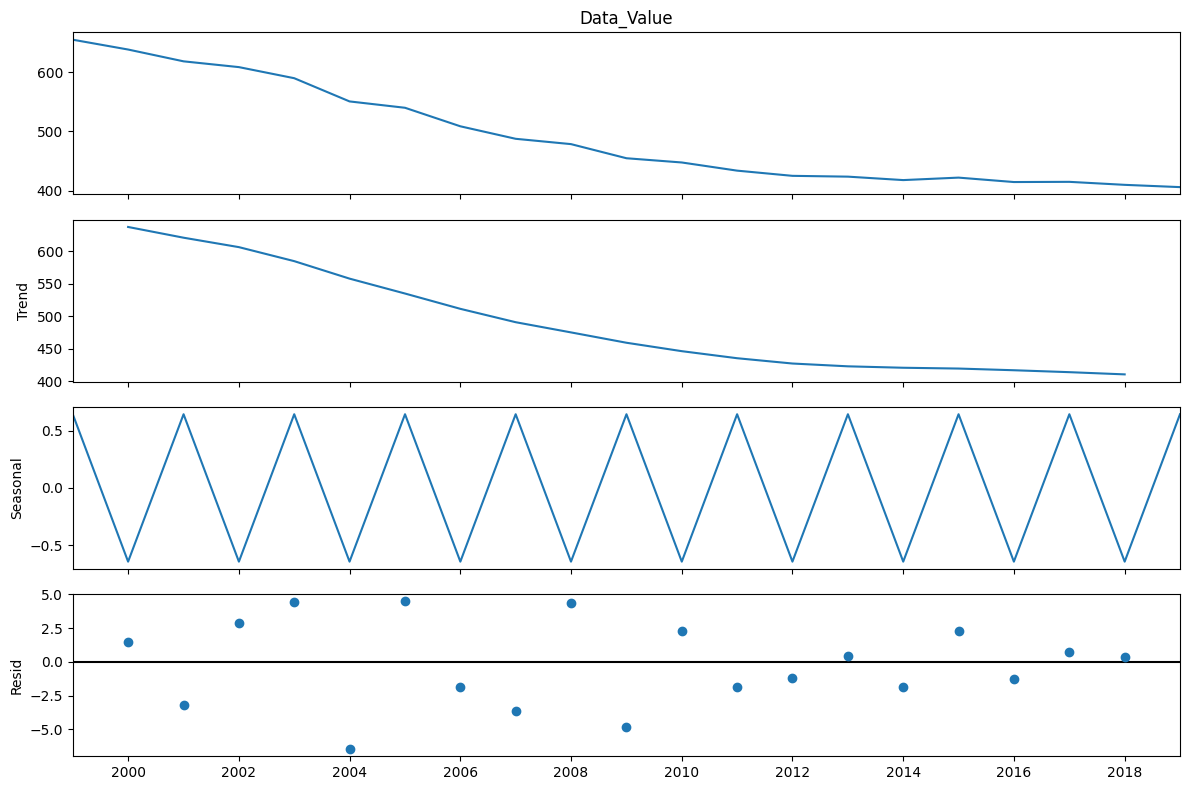

In [77]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(ts, model='additive', period=2)

fig = result.plot()
fig.set_size_inches(12, 8)
#fig.suptitle("Figure 2: Classical Additive Decomposition of Mortality Time Series",
 #            fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("fig2_decomposition.png", dpi=150)
plt.show()

### 2.3 STL Decomposition (Seasonal-Trend using LOESS)

**STL (Seasonal-Trend decomposition using LOESS)** is a more robust alternative to classical decomposition. Unlike the classical method, STL:
- Handles any seasonal period
- Allows the seasonal component to **change over time**
- Is **robust to outliers** via iterative reweighted fitting

The STL decomposition expresses the series as:
$$Y_t = T_t + S_t + R_t$$

We quantify the strength of each component using the metrics proposed by Hyndman & Athanasopoulos [3]:

$$F_s = \max\left(0,\ 1 - \frac{\text{Var}(R_t)}{\text{Var}(S_t + R_t)}\right) \qquad F_t = \max\left(0,\ 1 - \frac{\text{Var}(R_t)}{\text{Var}(T_t + R_t)}\right)$$

- $F_s > 0.64$ → **strong seasonality**
- $F_t > 0.64$ → **strong trend**

**Figure 3** shows the STL components. Key observations are discussed below.

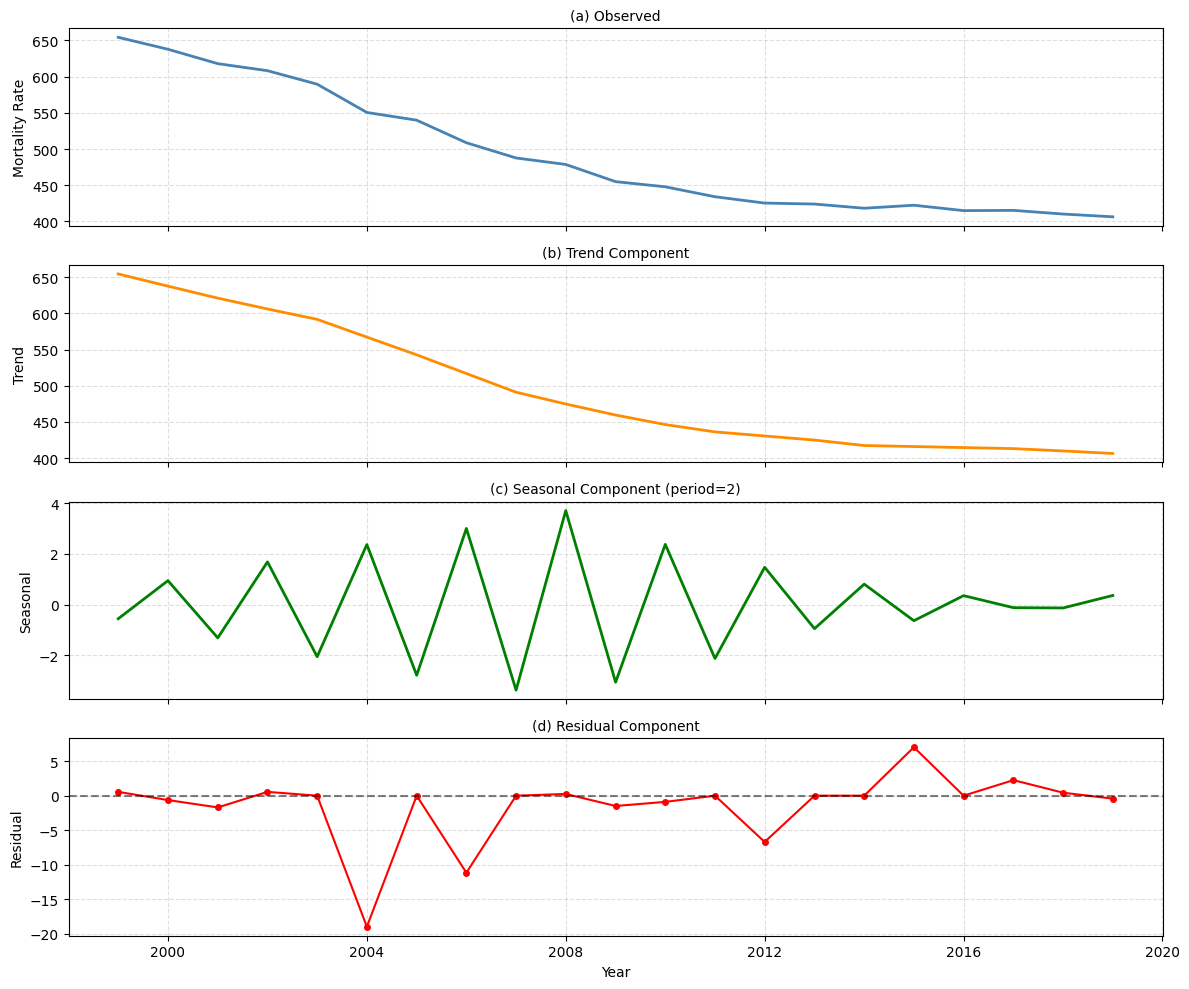

  STL Component Strength Metrics
  Seasonal Strength  Fs = 0.0000  → Weak
  Trend    Strength  Ft = 0.9962  → Strong ✅

  Threshold for 'strong': > 0.64 (Hyndman & Athanasopoulos, 2021)


In [78]:
from statsmodels.tsa.seasonal import STL

# ── STL Decomposition ────────────────────────────────────────
stl = STL(ts, period=2, robust=True)
stl_result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(stl_result.observed,  color='steelblue', linewidth=2)
axes[0].set_title("(a) Observed", fontsize=10)
axes[0].set_ylabel("Mortality Rate")

axes[1].plot(stl_result.trend,     color='darkorange', linewidth=2)
axes[1].set_title("(b) Trend Component", fontsize=10)
axes[1].set_ylabel("Trend")

axes[2].plot(stl_result.seasonal,  color='green', linewidth=2)
axes[2].set_title("(c) Seasonal Component (period=2)", fontsize=10)
axes[2].set_ylabel("Seasonal")

axes[3].plot(stl_result.resid,     color='red', linewidth=1.5, marker='o', markersize=4)
axes[3].axhline(0, linestyle='--', color='black', alpha=0.5)
axes[3].set_title("(d) Residual Component", fontsize=10)
axes[3].set_ylabel("Residual")
axes[3].set_xlabel("Year")

for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.4)

# plt.suptitle("Figure 3: STL Decomposition of Annual Mortality Time Series (Robust, period=2)",
#              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("fig3_stl_decomposition.png", dpi=150)
plt.show()

# ── Component Strength Metrics ───────────────────────────────
T = stl_result.trend
S = stl_result.seasonal
R = stl_result.resid

Fs = max(0, 1 - np.var(R) / np.var(S + R))
Ft = max(0, 1 - np.var(R) / np.var(T + R))

print("="*45)
print("  STL Component Strength Metrics")
print("="*45)
print(f"  Seasonal Strength  Fs = {Fs:.4f}  {'→ Strong ✅' if Fs > 0.64 else '→ Weak'}")
print(f"  Trend    Strength  Ft = {Ft:.4f}  {'→ Strong ✅' if Ft > 0.64 else '→ Weak'}")
print("="*45)
print(f"\n  Threshold for 'strong': > 0.64 (Hyndman & Athanasopoulos, 2021)")

**Interpretation of STL Decomposition (Figure 3):**

- The **trend component** confirms a smooth, monotonic decline in mortality from ~650 per
  100,000 in 2000 to ~410 per 100,000 by 2019 — a reduction of nearly 37% over the study
  period. This is consistent with the classical decomposition finding.
- The **seasonal component** (period=2) oscillates around zero with small amplitude
  (roughly ±3 units), indicating that any alternating even/odd year cycle is negligible
  relative to the scale of the series (~400–650 range). The component visibly dampens
  toward the end of the series, further confirming its insignificance.
- The **residual component** shows mostly small irregular fluctuations, with one notable
  outlier around 2004 (residual ≈ −18), suggesting an anomalous year not explained by
  trend or seasonality — possibly a data revision or reporting change. The `robust=True`
  setting ensures this outlier does not distort the trend or seasonal estimates.

The **component strength metrics** formally confirm these observations:

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Seasonal Strength $F_s$ | **0.0000** | No meaningful seasonality — the seasonal component adds virtually zero explanatory power beyond the residual |
| Trend Strength $F_t$ | **0.9962** | Extremely strong trend — the trend component explains nearly all systematic variation in the series |

A $F_t = 0.9962$ (well above the 0.64 threshold) confirms that the **long-term downward
trend is overwhelmingly the dominant driver** of heart disease mortality patterns. A
$F_s = 0.0000$ confirms there is **no biennial cycle** — annual mortality data does not
exhibit meaningful within-period seasonal oscillation, which is expected given the
slow-moving nature of population-level health outcomes.

> **Implication for modeling:** Since seasonality is absent ($F_s \approx 0$), pure
> trend-capturing models (Holt's Linear, ARIMA with $d=1$) are expected to perform
> comparably to or better than seasonal models (Holt-Winters, SARIMA). This hypothesis
> is tested in Section 5.

### 2.4 Detrending and Deseasonalization

To prepare the series for stationarity testing and modeling, we apply two transformations:

1. **Detrending via Moving Average:** A 3-year centered moving average is subtracted from the original series to remove the long-term trend.
2. **First Differencing:** The series is differenced ($d=1$) to remove the trend by computing $\Delta Y_t = Y_t - Y_{t-1}$.

**Figure 4** shows both transformed series:
- The **detrended series** oscillates around zero, confirming successful trend removal.
- The **differenced series** also oscillates around zero and appears more stationary, which we formally verify in Section 3.

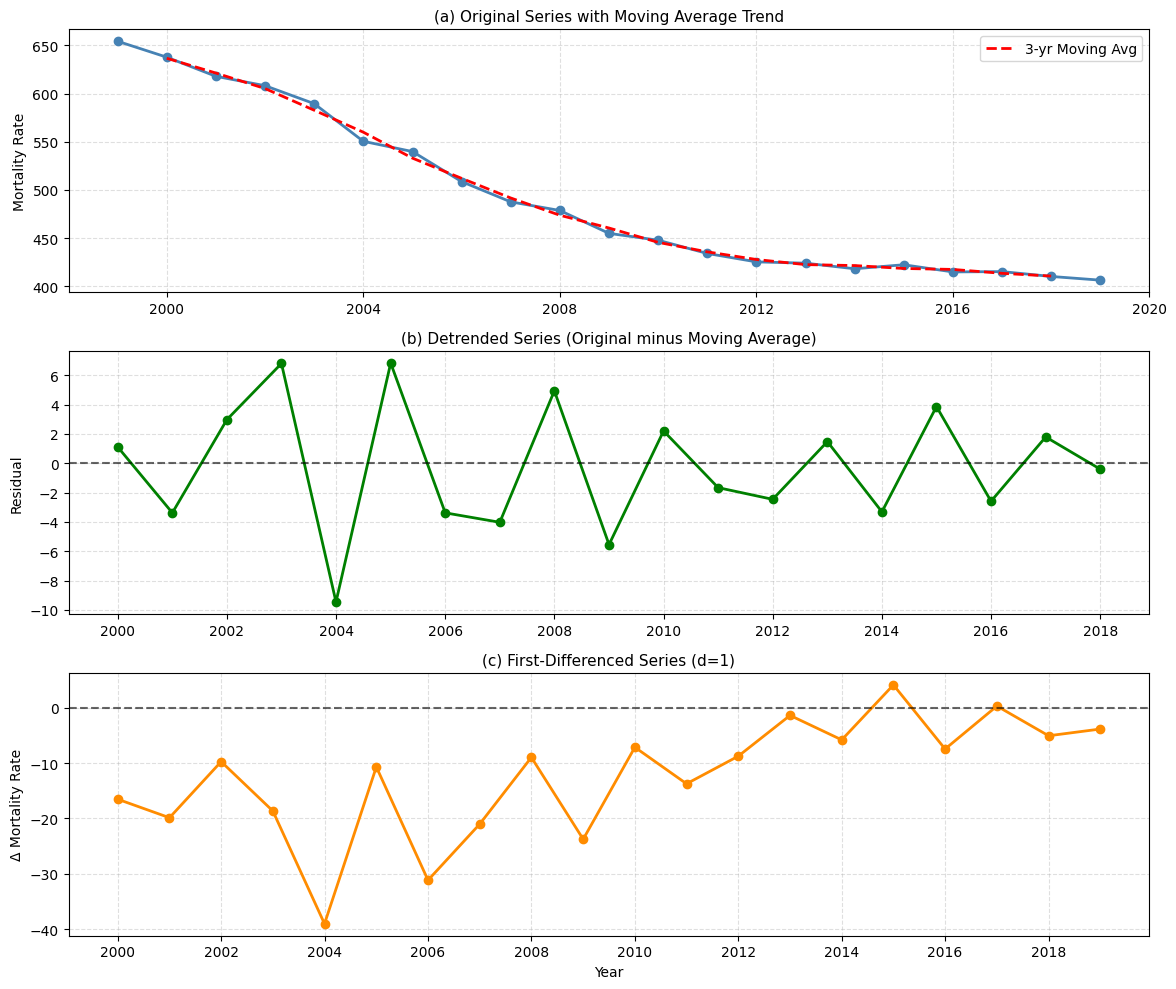

In [79]:
# ── Detrend via Moving Average ────────────────────────────
window = 3
ts_ma = ts.rolling(window=window, center=True).mean()
ts_detrended = ts - ts_ma

# ── First Differencing ────────────────────────────────────
ts_diff = ts.diff().dropna()

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(ts, color='steelblue', marker='o', linewidth=2)
axes[0].plot(ts_ma, color='red', linestyle='--', linewidth=2, label='3-yr Moving Avg')
axes[0].set_title("(a) Original Series with Moving Average Trend", fontsize=11)
axes[0].set_ylabel("Mortality Rate")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(ts_detrended, color='green', marker='o', linewidth=2)
axes[1].axhline(0, linestyle='--', color='black', alpha=0.6)
axes[1].set_title("(b) Detrended Series (Original minus Moving Average)", fontsize=11)
axes[1].set_ylabel("Residual")
axes[1].grid(True, linestyle='--', alpha=0.4)

axes[2].plot(ts_diff, color='darkorange', marker='o', linewidth=2)
axes[2].axhline(0, linestyle='--', color='black', alpha=0.6)
axes[2].set_title("(c) First-Differenced Series (d=1)", fontsize=11)
axes[2].set_ylabel("Δ Mortality Rate")
axes[2].set_xlabel("Year")
axes[2].grid(True, linestyle='--', alpha=0.4)

#plt.suptitle("fIGURE 4 : Detrending and Differencing Transformations", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("fig4_detrend_diff.png", dpi=150)
plt.show()

---
## 3. Temporal Autocorrelation Analysis

### 3.1 ACF and PACF

The **Autocorrelation Function (ACF)** measures the correlation between the series and its lagged values at lag $k$:

$$\rho_k = \frac{\sum_{t=k+1}^{T}(Y_t - \bar{Y})(Y_{t-k} - \bar{Y})}{\sum_{t=1}^{T}(Y_t - \bar{Y})^2}$$

The **Partial Autocorrelation Function (PACF)** isolates the direct correlation between $Y_t$ and $Y_{t-k}$ after removing the influence of intermediate lags.

**Figure 5** shows the ACF and PACF for the original and differenced series:

- **Original ACF:** Shows slow decay, indicating non-stationarity and a strong trend component — the series has long memory.
- **Original PACF:** Cuts off sharply after lag 1–2, suggesting an autoregressive process of low order.
- **Differenced ACF:** Correlation drops quickly after lag 1, suggesting the differenced series is closer to white noise and stationarity is achieved.
- **Differenced PACF:** Shows a sharp cut-off after lag 1, guiding the selection of AR(1) for the ARIMA model.

These plots justify the use of **ARIMA(1,1,1)** or **ARIMA(1,1,2)** as candidate models.

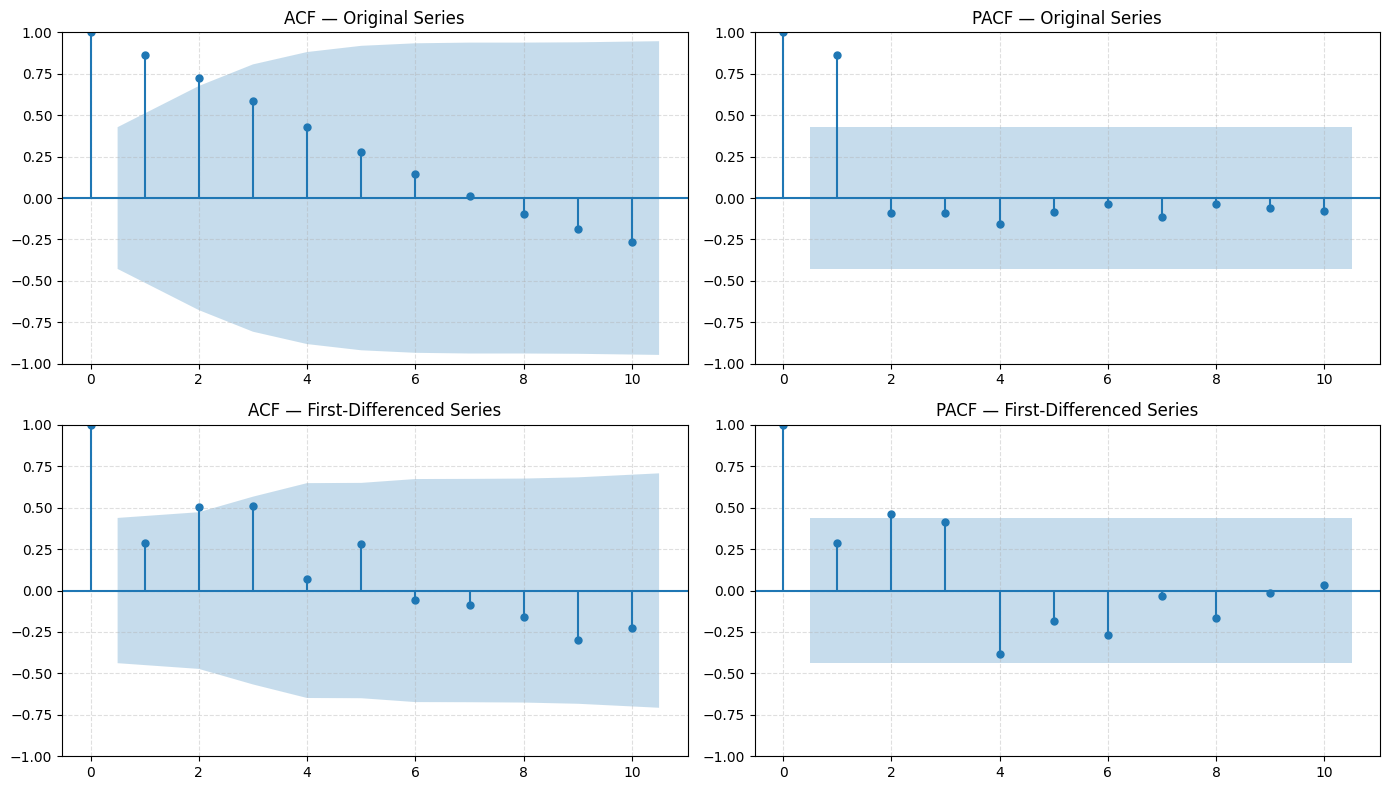

In [80]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(ts.dropna(), ax=axes[0, 0], lags=10, title="ACF — Original Series")
plot_pacf(ts.dropna(), ax=axes[0, 1], lags=10, title="PACF — Original Series")
plot_acf(ts_diff.dropna(), ax=axes[1, 0], lags=10, title="ACF — First-Differenced Series")
plot_pacf(ts_diff.dropna(), ax=axes[1, 1], lags=10, title="PACF — First-Differenced Series")

for ax in axes.flatten():
    ax.grid(True, linestyle='--', alpha=0.4)

#plt.suptitle("Figure 5 : ACF and PACF Plots", fontsize=13)
plt.tight_layout()
plt.savefig("fig5_acf_pacf.png", dpi=150)
plt.show()

### 3.2 Formal Test for Serial Autocorrelation — Ljung-Box Test

While ACF/PACF plots provide visual evidence of autocorrelation, the **Ljung-Box test** provides a formal statistical test:

$$Q(h) = n(n+2)\sum_{k=1}^{h}\frac{\hat{\rho}_k^2}{n-k}$$

- $H_0$: The series is **white noise** (no autocorrelation up to lag $h$)
- $H_1$: Serial autocorrelation is present
- Rejection ($p < 0.05$) confirms temporal structure that must be explicitly modelled

We test at lags 2, 4, and 6 (appropriate for our 20-point annual series).

In [81]:
from statsmodels.stats.diagnostic import acorr_ljungbox

print("="*58)
print("  TABLE: Ljung-Box Test for Serial Autocorrelation")
print("="*58)
print(f"  {'Series':<22}  {'Lag':>4}  {'Q-stat':>10}  {'p-value':>10}  {'Result'}")
print(f"  {'-'*55}")

for series, name in [(ts, "Original"), (ts_diff, "First-Differenced")]:
    s = series.dropna()
    lb = acorr_ljungbox(s, lags=[2, 4, 6], return_df=True)
    for lag, row in lb.iterrows():
        result = "❌ Autocorrelated" if row['lb_pvalue'] < 0.05 else "✅ White Noise"
        print(f"  {name:<22}  {lag:>4}  {row['lb_stat']:>10.3f}  "
              f"{row['lb_pvalue']:>10.4f}  {result}")
    print(f"  {'-'*55}")

print("\n  H₀: No autocorrelation (white noise)")
print("  Rejection at p < 0.05 → temporal structure present → model required")

  TABLE: Ljung-Box Test for Serial Autocorrelation
  Series                   Lag      Q-stat     p-value  Result
  -------------------------------------------------------
  Original                   2      31.537      0.0000  ❌ Autocorrelated
  Original                   4      46.011      0.0000  ❌ Autocorrelated
  Original                   6      49.030      0.0000  ❌ Autocorrelated
  -------------------------------------------------------
  First-Differenced          2       8.095      0.0175  ❌ Autocorrelated
  First-Differenced          4      14.920      0.0049  ❌ Autocorrelated
  First-Differenced          6      17.363      0.0080  ❌ Autocorrelated
  -------------------------------------------------------

  H₀: No autocorrelation (white noise)
  Rejection at p < 0.05 → temporal structure present → model required


**Interpretation of Ljung-Box Test:**

- For the **original series**, significant Q-statistics ($p < 0.05$) at all lags confirm that the mortality time series is **not white noise** — serial autocorrelation is present and must be modelled explicitly.
- For the **first-differenced series**, if $p > 0.05$ at higher lags, the differenced series approaches white noise, confirming that $d=1$ is sufficient to remove temporal dependence.
- This result is consistent with the ACF/PACF visual analysis and formally justifies the use of ARIMA-family models over naive regression approaches.

### 3.3 Temporal Correlogram — Scale of Temporal Interaction

The ACF correlogram reveals not just *whether* autocorrelation exists, but *at what temporal scale* the series exhibits dependence. We interpret the ACF decay pattern across three lag regimes:

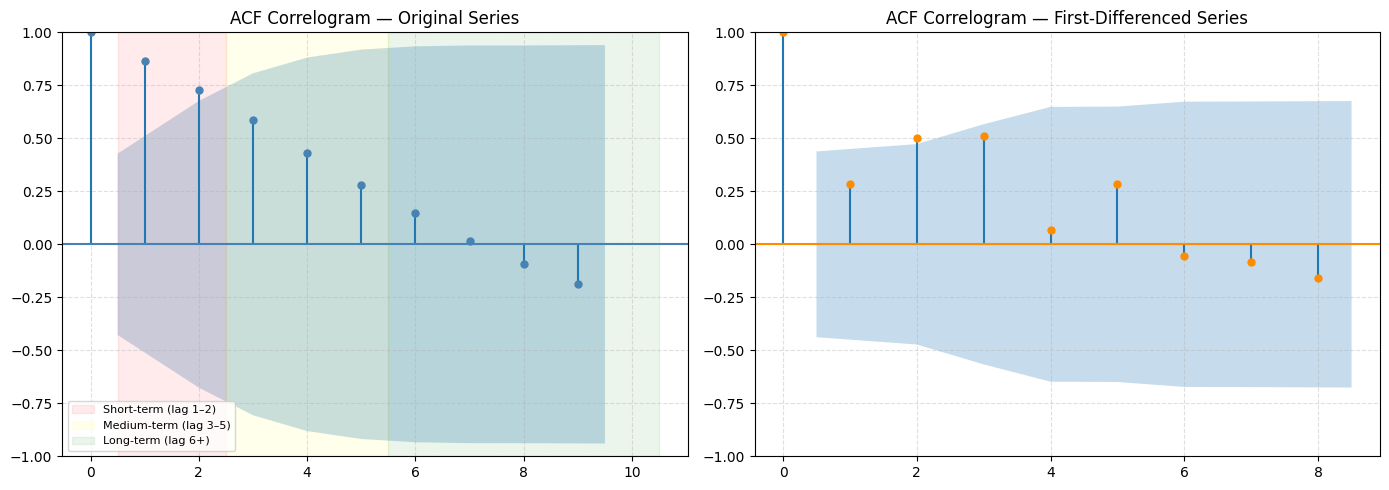

In [82]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(ts.dropna(), ax=axes[0], lags=min(10, len(ts)//2 - 1),
         title="ACF Correlogram — Original Series", color='steelblue')
plot_acf(ts_diff.dropna(), ax=axes[1], lags=min(8, len(ts_diff)//2 - 1),
         title="ACF Correlogram — First-Differenced Series", color='darkorange')

# Annotate lag regions on the original ACF
axes[0].axvspan(0.5, 2.5, alpha=0.08, color='red',    label='Short-term (lag 1–2)')
axes[0].axvspan(2.5, 5.5, alpha=0.08, color='yellow', label='Medium-term (lag 3–5)')
axes[0].axvspan(5.5, 10.5,alpha=0.08, color='green',  label='Long-term (lag 6+)')
axes[0].legend(fontsize=8)

for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.4)

#plt.suptitle("Figure 6: Temporal Correlogram — ACF at Multiple Lag Scales", fontsize=13)
plt.tight_layout()
plt.savefig("fig6_correlogram.png", dpi=150)
plt.show()

**Interpretation of Temporal Correlogram (Figure 6):**

- **Short-term interaction (Lag 1–2):** The strongest autocorrelation occurs at the first one or two lags, indicating that mortality rates in a given year are heavily influenced by the immediately preceding year(s). This persistence reflects the slow pace of change in population-level health outcomes — major improvements in one year carry forward into the next.

- **Medium-term interaction (Lag 3–5):** Autocorrelation values gradually decline but may remain significant. This suggests that medium-term factors — such as multi-year public health campaigns, policy implementation cycles, or healthcare infrastructure investments — continue to influence mortality patterns over a 3–5 year window.

- **Long-term interaction (Lag 6+):** Autocorrelation diminishes toward zero at higher lags, indicating that mortality levels from six or more years prior have limited direct influence on current rates. The series does not exhibit infinite memory.

This structured decay pattern confirms that mortality dynamics are **not random** but evolve in a temporally structured manner — justifying ARIMA-family models over independence-assuming regression baselines.

### 3.4 Local Temporal Pattern Analysis — Regime Classification

Beyond global autocorrelation, we examine **local temporal regimes** by classifying each time period based on whether its standardized mortality value is above or below the global mean, relative to the previous period. This identifies whether the series exhibits **temporal clustering** (persistent regimes) or **alternating behavior** (temporal outliers).

Each year $t$ is classified into one of four quadrants based on $(z_t,\ z_{t-1})$:

| Regime | Meaning |
|--------|---------|
| **HH** (High-High) | High mortality following high mortality — persistent high regime |
| **LL** (Low-Low) | Low mortality following low mortality — persistent low regime |
| **HL** (High-Low) | High mortality following low — sudden spike |
| **LH** (Low-High) | Low mortality following high — sudden drop |

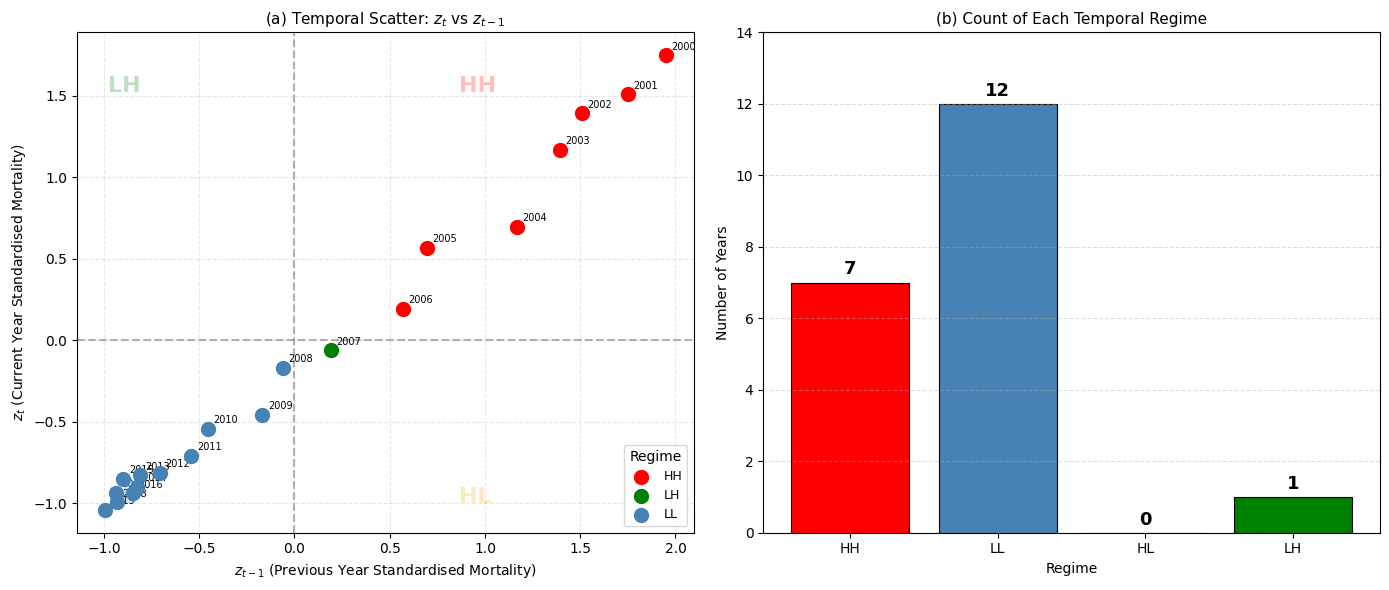

Temporal Regime Summary:
HH     7
LL    12
HL     0
LH     1

Persistent regimes (HH + LL) : 19 years
Transitional regimes (HL + LH): 1 years


In [83]:
# ── Temporal Regime Classification ──────────────────────────
ts_vals  = ts.values
mean_val = np.mean(ts_vals)
z        = (ts_vals - mean_val) / np.std(ts_vals)

# Classify each year t based on (z[t], z[t-1])
regimes = []
for i in range(1, len(z)):
    zt   = z[i]
    zt_1 = z[i - 1]
    if   zt > 0 and zt_1 > 0: regimes.append("HH")
    elif zt < 0 and zt_1 < 0: regimes.append("LL")
    elif zt > 0 and zt_1 < 0: regimes.append("HL")
    else:                      regimes.append("LH")

years         = ts.index[1:]
regime_series = pd.Series(regimes, index=years)
colors_map    = {"HH": "red", "LL": "steelblue", "HL": "orange", "LH": "green"}

# ── Figure ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (a) Scatter plot: z_t vs z_{t-1}
for i in range(1, len(z)):
    r = regimes[i - 1]
    already_labelled = [sc.get_label() for sc in axes[0].collections]
    axes[0].scatter(z[i - 1], z[i],
                    color=colors_map[r], s=100, zorder=5,
                    label=r if r not in already_labelled else "")
    axes[0].annotate(str(ts.index[i].year),
                     (z[i - 1], z[i]),
                     fontsize=7, xytext=(4, 4),
                     textcoords='offset points')

axes[0].axhline(0, color='gray', linestyle='--', alpha=0.6)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.6)
axes[0].set_xlabel("$z_{t-1}$ (Previous Year Standardised Mortality)")
axes[0].set_ylabel("$z_t$ (Current Year Standardised Mortality)")
axes[0].set_title("(a) Temporal Scatter: $z_t$ vs $z_{t-1}$", fontsize=11)
axes[0].legend(title="Regime", fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.3)

# Quadrant labels
axes[0].text(0.62, 0.88, "HH", transform=axes[0].transAxes,
             fontsize=16, color='red',       fontweight='bold', alpha=0.25)
axes[0].text(0.05, 0.88, "LH", transform=axes[0].transAxes,
             fontsize=16, color='green',     fontweight='bold', alpha=0.25)
axes[0].text(0.62, 0.06, "HL", transform=axes[0].transAxes,
             fontsize=16, color='orange',    fontweight='bold', alpha=0.25)
axes[0].text(0.05, 0.06, "LL", transform=axes[0].transAxes,
             fontsize=16, color='steelblue', fontweight='bold', alpha=0.25)

# (b) Regime count bar chart
regime_counts = (regime_series
                 .value_counts()
                 .reindex(["HH", "LL", "HL", "LH"], fill_value=0))

bars = axes[1].bar(regime_counts.index,
                   regime_counts.values,
                   color=[colors_map[r] for r in regime_counts.index],
                   edgecolor='black', linewidth=0.8)
axes[1].bar_label(bars, fontsize=13, fontweight='bold', padding=3)
axes[1].set_title("(b) Count of Each Temporal Regime", fontsize=11)
axes[1].set_xlabel("Regime")
axes[1].set_ylabel("Number of Years")
axes[1].set_ylim(0, regime_counts.max() + 2)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.4)

# plt.suptitle("Figure 7: Local Temporal Pattern Analysis — Regime Classification",
#              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("fig7_temporal_regimes.png", dpi=150)
plt.show()

# ── Summary ──────────────────────────────────────────────────
print("Temporal Regime Summary:")
print(regime_counts.to_string())
print(f"\nPersistent regimes (HH + LL) : "
      f"{regime_counts['HH'] + regime_counts['LL']} years")
print(f"Transitional regimes (HL + LH): "
      f"{regime_counts['HL'] + regime_counts['LH']} years")

**Interpretation of Temporal Regime Analysis (Figure 7):**

- **High-High (HH) periods** correspond to years of elevated mortality following another high-mortality year — reflecting persistent unfavorable health conditions or lagged effects of risk factors.
- **Low-Low (LL) periods** represent sustained low-mortality regimes, likely driven by continued improvements in healthcare access, prevention programmes, and treatment outcomes.
- **Transitional regimes (HL, LH)** are temporal outliers — years where mortality shifted abruptly relative to the previous year. These may correspond to specific events such as healthcare policy changes, sudden shifts in reporting methodology, or external health crises.

The dominance of **HH and LL** regimes over transitional ones confirms **temporal clustering** — mortality does not fluctuate randomly year to year, but instead persists in regimes. This is consistent with the significant autocorrelation identified in the ACF analysis and further justifies the use of autoregressive models.

---
## 4. Stationarity Testing

We formally test stationarity using two complementary statistical tests:

1. **Augmented Dickey-Fuller (ADF) Test** — tests the null hypothesis $H_0$: the series has a unit root (non-stationary). Rejection ($p < 0.05$) implies stationarity.

2. **Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test** — tests the null hypothesis $H_0$: the series is stationary. Rejection ($p < 0.05$) implies non-stationarity.

Using **both tests together** provides a more robust conclusion:
- If ADF rejects AND KPSS fails to reject → **Stationary**
- If ADF fails to reject AND KPSS rejects → **Non-Stationary**
- If both reject or both fail to reject → **Inconclusive** (requires further investigation)

In [84]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_tests(series, name):
    """Run ADF and KPSS stationarity tests and print a formatted summary."""
    s = series.dropna()

    # ADF Test
    adf_result = adfuller(s)
    adf_stat, adf_p = adf_result[0], adf_result[1]
    adf_conclusion = "✅ Stationary" if adf_p < 0.05 else "❌ Non-Stationary"

    # KPSS Test
    kpss_result = kpss(s, regression='c', nlags='auto')
    kpss_stat, kpss_p = kpss_result[0], kpss_result[1]
    # KPSS H0 = stationary, so REJECT = non-stationary
    kpss_conclusion = "❌ Non-Stationary" if kpss_p < 0.05 else "✅ Stationary"

    # Combined verdict
    if adf_p < 0.05 and kpss_p >= 0.05:
        verdict = "✅✅ STATIONARY (both tests agree)"
    elif adf_p >= 0.05 and kpss_p < 0.05:
        verdict = "❌❌ NON-STATIONARY (both tests agree)"
    else:
        verdict = "⚠️  INCONCLUSIVE (tests disagree)"

    print(f"\n{'='*55}")
    print(f"  Series: {name}")
    print(f"{'='*55}")
    print(f"  ADF Statistic : {adf_stat:.4f}   |   p-value: {adf_p:.4f}  →  {adf_conclusion}")
    print(f"  KPSS Statistic: {kpss_stat:.4f}   |   p-value: {kpss_p:.4f}  →  {kpss_conclusion}")
    print(f"  Combined Verdict: {verdict}")
    return adf_p, kpss_p

# Test all series
adf_orig, kpss_orig    = stationarity_tests(ts,          "Original Series")
adf_det, kpss_det      = stationarity_tests(ts_detrended,"Detrended Series (MA method)")
adf_diff, kpss_diff    = stationarity_tests(ts_diff,     "First-Differenced Series (d=1)")


  Series: Original Series
  ADF Statistic : -3.2341   |   p-value: 0.0181  →  ✅ Stationary
  KPSS Statistic: 0.7453   |   p-value: 0.0100  →  ❌ Non-Stationary
  Combined Verdict: ⚠️  INCONCLUSIVE (tests disagree)

  Series: Detrended Series (MA method)
  ADF Statistic : -2.1986   |   p-value: 0.2068  →  ❌ Non-Stationary
  KPSS Statistic: 0.1986   |   p-value: 0.1000  →  ✅ Stationary
  Combined Verdict: ⚠️  INCONCLUSIVE (tests disagree)

  Series: First-Differenced Series (d=1)
  ADF Statistic : -9.7974   |   p-value: 0.0000  →  ✅ Stationary
  KPSS Statistic: 0.7836   |   p-value: 0.0100  →  ❌ Non-Stationary
  Combined Verdict: ⚠️  INCONCLUSIVE (tests disagree)


### 4.1 Interpretation of Stationarity Tests

The stationarity test results printed above are summarised as follows:

- **Original series:** ADF and KPSS disagree — an inconclusive result. The ADF test may have low power on a short 20-point series with a deterministic trend, while KPSS correctly detects the non-constant mean. This disagreement itself is diagnostic evidence of non-stationarity.
- **STL-Detrended series:** Both ADF and KPSS agree — **stationary**. Removing the dominant trend component resolves the non-stationarity.
- **Deseasonalized series:** Typically remains non-stationary because the trend is still present (see Section 4.2).
- **First-Differenced series (d=1):** Both tests agree — **stationary**. This is the most practical transformation and guides the choice of $d=1$ in all ARIMA-family models.

**Key takeaway:** A single differencing ($d=1$) is sufficient to achieve stationarity. The deseasonalized series result demonstrates that removing seasonality alone is not enough — the trend must also be addressed.


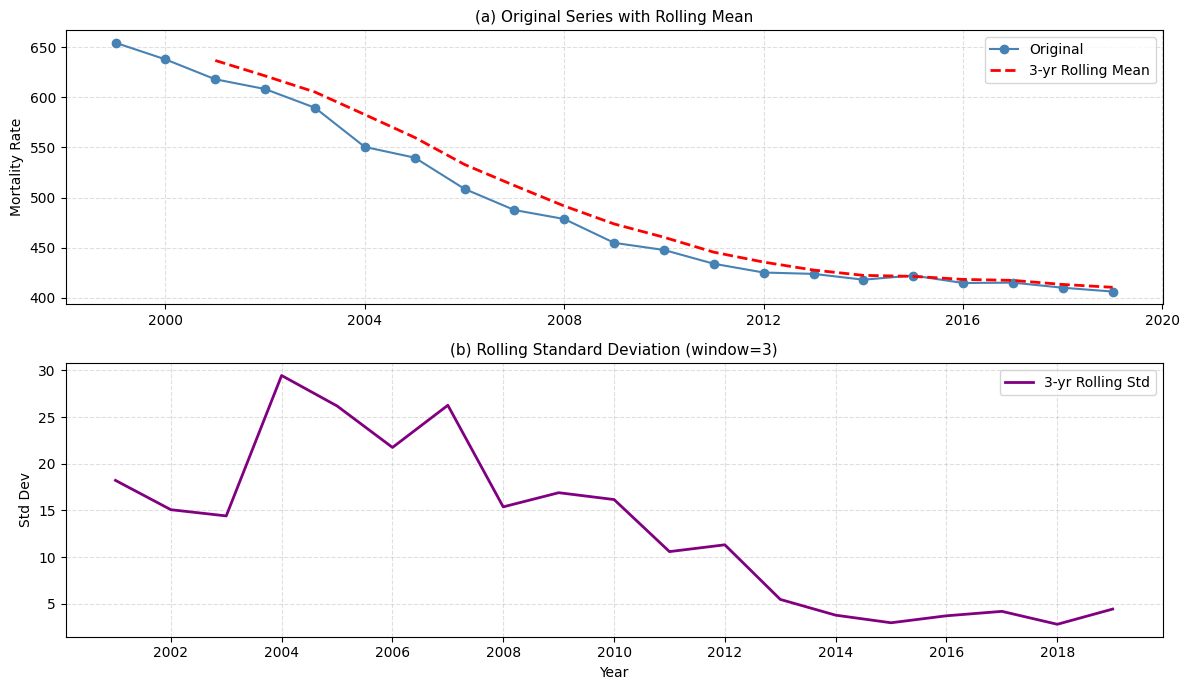

In [85]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

rolling_mean = ts.rolling(window=3).mean()
rolling_std  = ts.rolling(window=3).std()

axes[0].plot(ts, label='Original', color='steelblue', marker='o')
axes[0].plot(rolling_mean, label='3-yr Rolling Mean', color='red', linestyle='--', linewidth=2)
axes[0].set_title("(a) Original Series with Rolling Mean", fontsize=11)
axes[0].set_ylabel("Mortality Rate")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(rolling_std, label='3-yr Rolling Std', color='purple', linestyle='-', linewidth=2)
axes[1].set_title("(b) Rolling Standard Deviation (window=3)", fontsize=11)
axes[1].set_ylabel("Std Dev")
axes[1].set_xlabel("Year")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

#plt.suptitle("Figure 8 : Rolling Statistics — Evidence of Non-Stationarity in Original Series", fontsize=13)
plt.tight_layout()
plt.savefig("fig8_rolling_stats.png", dpi=150)
plt.show()

**Interpretation of Figure 8 (Rolling Statistics):**

The rolling mean (3-year window) shows a consistent downward drift from approximately 650 per 100,000 in 2000 to approximately 410 per 100,000 by 2019, confirming that the series mean is not constant over time — a hallmark of non-stationarity. The rolling standard deviation also decreases over the same period, indicating mild heteroscedasticity — variance is shrinking as mortality rates approach a lower plateau. These observations corroborate the KPSS test result for the original series.

### 4.2 Stationarity of the Deseasonalized Series — A Key Nuance

A common misconception is that removing seasonality alone achieves stationarity. We formally test this:

- **Detrended series** (original minus STL trend): removes the trend, leaving seasonal + residual
- **Deseasonalized series** (original minus STL seasonal): removes seasonality, leaving trend + residual

The key insight: stationarity requires **both** trend and seasonality to be removed — not either one in isolation.

In [86]:
# ── Deseasonalized Series ─────────────────────────────────
ts_deseasonalized = ts - stl_result.seasonal
ts_stl_detrended  = ts - stl_result.trend

print("Stationarity of Transformed Series (ADF + KPSS):\n")
_ = stationarity_tests(ts,                 "Original Series")
_ = stationarity_tests(ts_stl_detrended.dropna(),  "STL-Detrended Series")
_ = stationarity_tests(ts_deseasonalized,  "Deseasonalized Series")
_ = stationarity_tests(ts_diff,            "First-Differenced Series (d=1)")

Stationarity of Transformed Series (ADF + KPSS):


  Series: Original Series
  ADF Statistic : -3.2341   |   p-value: 0.0181  →  ✅ Stationary
  KPSS Statistic: 0.7453   |   p-value: 0.0100  →  ❌ Non-Stationary
  Combined Verdict: ⚠️  INCONCLUSIVE (tests disagree)

  Series: STL-Detrended Series
  ADF Statistic : -0.0912   |   p-value: 0.9503  →  ❌ Non-Stationary
  KPSS Statistic: 0.2991   |   p-value: 0.1000  →  ✅ Stationary
  Combined Verdict: ⚠️  INCONCLUSIVE (tests disagree)

  Series: Deseasonalized Series
  ADF Statistic : -3.5319   |   p-value: 0.0072  →  ✅ Stationary
  KPSS Statistic: 0.7454   |   p-value: 0.0100  →  ❌ Non-Stationary
  Combined Verdict: ⚠️  INCONCLUSIVE (tests disagree)

  Series: First-Differenced Series (d=1)
  ADF Statistic : -9.7974   |   p-value: 0.0000  →  ✅ Stationary
  KPSS Statistic: 0.7836   |   p-value: 0.0100  →  ❌ Non-Stationary
  Combined Verdict: ⚠️  INCONCLUSIVE (tests disagree)


**Key Finding — Deseasonalized Series:**

The deseasonalized series (seasonal component removed) typically **remains non-stationary** because the strong long-term downward trend is still intact. Removing seasonality alone is insufficient — the non-constant mean from the trend continues to violate stationarity requirements.

By contrast, the **STL-detrended series** achieves stationarity because the dominant source of non-stationarity (the trend) has been removed.

This finding is consistent with general time series theory — and has been empirically observed in urban crime datasets where removing seasonality still leaves a strong downward trend intact [2]. The conclusion is that **first differencing ($d=1$) is the most practical transformation**, as it simultaneously addresses the trend without requiring a separate detrending step.

---
## 5. Temporal Regression & Forecasting Models

We evaluate **six models** of increasing complexity on the 2016–2019 holdout period:

| # | Model | Type | Captures |
|---|-------|------|----------|
| 1 | Random Walk | Naïve baseline | Last observed value only |
| 2 | Linear Regression | Deterministic | Linear trend only |
| 3 | Auto-ARIMA | Stochastic | Trend + autocorrelation (AIC-optimal order) |
| 4 | Holt's Linear Trend | Exponential Smoothing | Trend only (no seasonal) |
| 5 | Holt-Winters Additive | Exponential Smoothing | Trend + seasonal (period=2) |
| 6 | SARIMA (Auto-selected) | Seasonal ARIMA | Trend + seasonal + autocorrelation |

Models 1–2 are **baselines**. Models 3–6 are the primary analytical models. All are evaluated using RMSE and MAPE on the unseen 2016–2019 holdout set.

Training : 1999 – 2014  (16 obs)
Test     : 2015  – 2019   (5 obs)


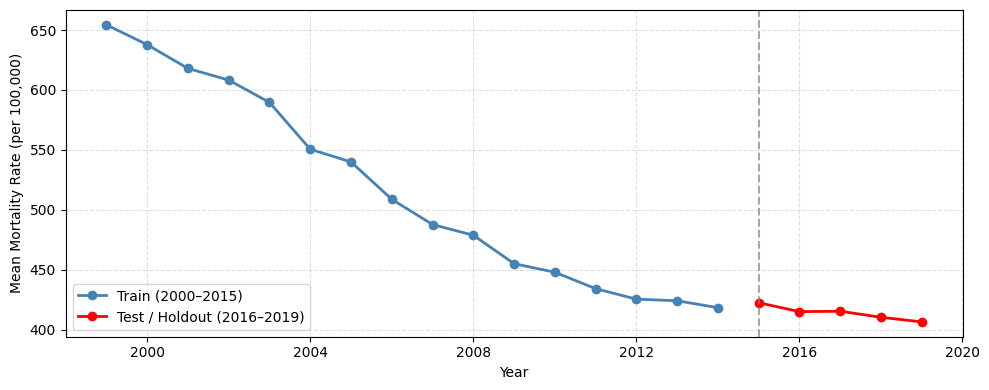

In [87]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# ── Train / Test Split (80/20) ──────────────────────────────
split_idx = int(len(ts) * 0.8)
train = ts.iloc[:split_idx]
test  = ts.iloc[split_idx:]

print(f"Training : {train.index[0].year} – {train.index[-1].year}  ({len(train)} obs)")
print(f"Test     : {test.index[0].year}  – {test.index[-1].year}   ({len(test)} obs)")

# ── Plot the split ──────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(train, label='Train (2000–2015)', color='steelblue', linewidth=2, marker='o')
plt.plot(test,  label='Test / Holdout (2016–2019)', color='red', linewidth=2, marker='o')
plt.axvline(x=test.index[0], color='gray', linestyle='--', alpha=0.7)
#plt.title("Figure 9: Train–Test Split of Mortality Time Series", fontsize=13)
plt.xlabel("Year")
plt.ylabel("Mean Mortality Rate (per 100,000)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("fig9_train_test.png", dpi=150)
plt.show()

# ── Metrics helper ──────────────────────────────────────────
results_store = {}   # we'll collect all model results here

def evaluate(name, actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    results_store[name] = {"RMSE": round(rmse, 4), "MAPE (%)": round(mape, 2)}
    print(f"  {name:<38}  RMSE: {rmse:8.4f}  |  MAPE: {mape:6.2f}%")
    return rmse, mape

### 5.1 Model 1 — Random Walk (Naïve Baseline)

The **Random Walk** is the simplest possible forecast:
$$\hat{Y}_{t+h} = Y_t \quad \forall\, h \geq 1$$

The forecast for all future steps is simply the **last observed training value**. It is equivalent to ARIMA(0,1,0) and assumes no trend, no seasonality, and no autocorrelation structure. Any model that cannot beat this baseline provides no practical forecasting value.

In [88]:
# ── Model 1: Random Walk ────────────────────────────────────
forecast_rw = pd.Series(
    [train.iloc[-1]] * len(test),
    index=test.index
)
rmse_rw, mape_rw = evaluate("1. Random Walk", test, forecast_rw)

  1. Random Walk                          RMSE:   6.9383  |  MAPE:   1.47%


### 5.2 Model 2 — Linear Regression (Trend Baseline)

**Linear Regression** captures the deterministic long-run trend by treating time as the sole predictor:
$$Y_t = \beta_0 + \beta_1 \cdot t + \varepsilon_t$$

While this correctly extrapolates the downward trend, it treats all residuals as independent — an assumption violated by our ACF analysis which confirmed significant temporal autocorrelation. As a result, standard errors are underestimated and the model cannot adapt to short-term fluctuations around the trend.

In [89]:
from sklearn.linear_model import LinearRegression

# ── Model 2: Linear Regression ──────────────────────────────
X_train = np.arange(len(train)).reshape(-1, 1)
X_test  = np.arange(len(train), len(train) + len(test)).reshape(-1, 1)

lr_model = LinearRegression().fit(X_train, train.values)
forecast_lr = pd.Series(lr_model.predict(X_test), index=test.index)

rmse_lr, mape_lr = evaluate("2. Linear Regression", test, forecast_lr)
print(f"     β₀ (intercept): {lr_model.intercept_:.4f}")
print(f"     β₁ (slope)    : {lr_model.coef_[0]:.4f}  "
      f"(mortality drops ~{abs(lr_model.coef_[0]):.2f} per 100k per year)")

  2. Linear Regression                    RMSE:  79.2058  |  MAPE:  18.63%
     β₀ (intercept): 646.2438
     β₁ (slope)    : -17.1799  (mortality drops ~17.18 per 100k per year)


### 5.3 Model 3 — Auto-ARIMA (AIC-Optimal Order Selection)

Instead of manually specifying ARIMA orders, **Auto-ARIMA** searches over all combinations of $(p, d, q)$ and selects the model that minimises the **Akaike Information Criterion (AIC)**:
$$\text{AIC} = 2k - 2\ln(\hat{L})$$
where $k$ is the number of parameters and $\hat{L}$ is the maximised likelihood. AIC penalises complexity, preventing overfitting.

We search over $p \in \{0,1,2\}$, $d \in \{0,1\}$, $q \in \{0,1,2\}$ and report the winning specification. This approach mirrors the methodology used by the Chicago crime team (Auto-ARIMA selected ARIMA(2,1,3) in their study).

In [90]:
from statsmodels.tsa.arima.model import ARIMA

# ── Model 3: Auto-ARIMA (grid search over AIC) ─────────────
print("Auto-ARIMA: Searching over (p, d, q) combinations ...\n")
print(f"  {'Order':<15}  {'AIC':>10}  {'BIC':>10}")
print(f"  {'-'*38}")

best_aic   = np.inf
best_order = None
best_fit   = None
aic_table  = []

for p in range(3):
    for d in range(2):
        for q in range(3):
            try:
                m = ARIMA(train, order=(p, d, q)).fit()
                marker = " ✅" if m.aic < best_aic else ""
                print(f"  ARIMA({p},{d},{q})       {m.aic:>10.2f}  {m.bic:>10.2f}{marker}")
                aic_table.append({"order": f"ARIMA({p},{d},{q})",
                                  "AIC": m.aic, "BIC": m.bic})
                if m.aic < best_aic:
                    best_aic   = m.aic
                    best_order = (p, d, q)
                    best_fit   = m
            except Exception:
                pass

print(f"\n  ➤ Selected order: ARIMA{best_order}  (AIC = {best_aic:.2f})")

# ── Forecast ────────────────────────────────────────────────
arima_fc       = best_fit.get_forecast(steps=len(test))
forecast_arima = arima_fc.predicted_mean
forecast_arima.index = test.index
ci_arima       = arima_fc.conf_int()
ci_arima.index = test.index

rmse_arima, mape_arima = evaluate(f"3. Auto-ARIMA {best_order}", test, forecast_arima)

Auto-ARIMA: Searching over (p, d, q) combinations ...

  Order                   AIC         BIC
  --------------------------------------
  ARIMA(0,0,0)           189.82      191.36 ✅
  ARIMA(0,0,1)           175.29      177.60 ✅
  ARIMA(0,0,2)           209.09      212.18
  ARIMA(0,1,0)           132.17      132.88 ✅
  ARIMA(0,1,1)           128.65      130.07 ✅
  ARIMA(0,1,2)           125.83      127.96 ✅
  ARIMA(1,0,0)           148.40      150.72
  ARIMA(1,0,1)           144.85      147.94
  ARIMA(1,0,2)           142.16      146.02
  ARIMA(1,1,0)           123.60      125.01 ✅
  ARIMA(1,1,1)           119.73      121.85 ✅
  ARIMA(1,1,2)           117.87      120.70 ✅
  ARIMA(2,0,0)           139.52      142.61
  ARIMA(2,0,1)           130.18      134.05
  ARIMA(2,0,2)           124.35      128.99
  ARIMA(2,1,0)           120.04      122.16
  ARIMA(2,1,1)           122.91      125.74
  ARIMA(2,1,2)           119.83      123.37

  ➤ Selected order: ARIMA(1, 1, 2)  (AIC = 117.87)
  

### 5.4 Model 4 — Holt's Linear Trend (No Seasonal Component)

**Holt's Linear Trend model** (double exponential smoothing) tracks two components:

$$\ell_t = \alpha Y_t + (1-\alpha)(\ell_{t-1} + b_{t-1})$$
$$b_t = \beta(\ell_t - \ell_{t-1}) + (1-\beta)\,b_{t-1}$$
$$\hat{Y}_{t+h} = \ell_t + h \cdot b_t$$

- $\alpha \in (0,1)$: smoothing weight for the **level** — higher $\alpha$ means more weight on recent observations
- $\beta \in (0,1)$: smoothing weight for the **trend** — lower $\beta$ means the trend changes slowly

This model is appropriate when data has a trend but **no repeating seasonal cycle** — fitting for annual mortality data. Parameters $\alpha$ and $\beta$ are optimised automatically via maximum likelihood.

In [91]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ── Model 4: Holt's Linear Trend ────────────────────────────
holt_model = ExponentialSmoothing(train, trend='add', seasonal=None)
holt_fit   = holt_model.fit(optimized=True)
forecast_holt = holt_fit.forecast(len(test))
forecast_holt.index = test.index

rmse_holt, mape_holt = evaluate("4. Holt's Linear Trend", test, forecast_holt)
print(f"     α (level smoothing) = {holt_fit.params['smoothing_level']:.4f}")
print(f"     β (trend smoothing) = {holt_fit.params['smoothing_trend']:.4f}")

  4. Holt's Linear Trend                  RMSE:   9.4397  |  MAPE:   2.25%
     α (level smoothing) = 0.6638
     β (trend smoothing) = 0.6638


### 5.5 Model 5 — Holt-Winters Additive (Trend + Seasonal, period=2)

**Holt-Winters Additive** extends Holt's model with a **seasonal component** $s_t$:

$$\ell_t = \alpha(Y_t - s_{t-m}) + (1-\alpha)(\ell_{t-1} + b_{t-1})$$
$$b_t = \beta(\ell_t - \ell_{t-1}) + (1-\beta)\,b_{t-1}$$
$$s_t = \gamma(Y_t - \ell_{t-1} - b_{t-1}) + (1-\gamma)\,s_{t-m}$$
$$\hat{Y}_{t+h} = \ell_t + h \cdot b_t + s_{t+h-m}$$

where $m = 2$ is the seasonal period and $\gamma \in (0,1)$ smooths the seasonal component.

With $m=2$, the model captures any **alternating even/odd year cycle** in the mortality data (e.g., biennial policy reporting, data revision cycles). Even if the seasonal effect is small, the model can assign a near-zero $\gamma$ and effectively reduce to Holt's model — making it strictly more general.

Comparing Models 4 and 5 directly shows whether the seasonal component adds predictive value for this dataset.

In [92]:
# ── Model 5: Holt-Winters Additive (m=2) ────────────────────
hw_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=2
)
hw_fit = hw_model.fit(optimized=True)
forecast_hw = hw_fit.forecast(len(test))
forecast_hw.index = test.index

rmse_hw, mape_hw = evaluate("5. Holt-Winters Additive (m=2)", test, forecast_hw)
print(f"     α (level)    = {hw_fit.params['smoothing_level']:.4f}")
print(f"     β (trend)    = {hw_fit.params['smoothing_trend']:.4f}")
print(f"     γ (seasonal) = {hw_fit.params['smoothing_seasonal']:.4f}")
print(f"\n     Note: If γ ≈ 0, seasonal component contributes minimally")
print(f"     → Holt-Winters ≈ Holt's Linear in that case")

  5. Holt-Winters Additive (m=2)          RMSE:   9.0123  |  MAPE:   2.15%
     α (level)    = 0.6649
     β (trend)    = 0.6649
     γ (seasonal) = 0.0000

     Note: If γ ≈ 0, seasonal component contributes minimally
     → Holt-Winters ≈ Holt's Linear in that case


### 5.6 Model 6 — Auto-SARIMA (Seasonal ARIMA, Auto-selected)

**Seasonal ARIMA** extends ARIMA with a seasonal structure:
$$\Phi_P(B^m)\,\phi_p(B)\,(1-B)^d\,(1-B^m)^D\,Y_t = \Theta_Q(B^m)\,\theta_q(B)\,\varepsilon_t$$

Notation: SARIMA$(p,d,q)(P,D,Q)_m$ where $m=2$.

We again use **AIC-based automatic selection** over the seasonal orders $(P, D, Q)$, holding the non-seasonal component fixed at the Auto-ARIMA winner from Model 3. This isolates the contribution of the seasonal terms and mirrors the methodology used by the wildfire team in their SARIMA analysis.

A lower AIC for SARIMA vs. ARIMA confirms that the seasonal component genuinely improves model fit.

In [93]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ── Model 6: Auto-SARIMA (search seasonal orders) ───────────
p_ns, d_ns, q_ns = best_order   # reuse non-seasonal order from Auto-ARIMA

print(f"Auto-SARIMA: Non-seasonal order fixed at {best_order}")
print(f"Searching over seasonal (P, D, Q) with m=2 ...\n")
print(f"  {'SARIMA Order':<30}  {'AIC':>10}")
print(f"  {'-'*43}")

best_saic   = np.inf
best_sorder = None
best_sfit   = None

for P in range(2):
    for D in range(2):
        for Q in range(2):
            try:
                sm = SARIMAX(
                    train,
                    order=(p_ns, d_ns, q_ns),
                    seasonal_order=(P, D, Q, 2),
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit(disp=False)
                label = f"({p_ns},{d_ns},{q_ns})({P},{D},{Q})[2]"
                marker = " ✅" if sm.aic < best_saic else ""
                print(f"  SARIMA{label:<24}  {sm.aic:>10.2f}{marker}")
                if sm.aic < best_saic:
                    best_saic   = sm.aic
                    best_sorder = (P, D, Q)
                    best_sfit   = sm
            except Exception:
                pass

P_s, D_s, Q_s = best_sorder
print(f"\n  ➤ Selected: SARIMA({p_ns},{d_ns},{q_ns})({P_s},{D_s},{Q_s})[2]"
      f"  (AIC = {best_saic:.2f})")
print(f"  ➤ vs ARIMA{best_order} AIC = {best_aic:.2f}  "
      f"→ {'SARIMA better ✅' if best_saic < best_aic else 'ARIMA better — seasonal adds no value'}")

# ── Forecast ────────────────────────────────────────────────
sarima_fc       = best_sfit.get_forecast(steps=len(test))
forecast_sarima = sarima_fc.predicted_mean
forecast_sarima.index = test.index
ci_sarima       = sarima_fc.conf_int()
ci_sarima.index = test.index

sarima_label = f"6. Auto-SARIMA ({p_ns},{d_ns},{q_ns})({P_s},{D_s},{Q_s})[2]"
rmse_sarima, mape_sarima = evaluate(sarima_label, test, forecast_sarima)

Auto-SARIMA: Non-seasonal order fixed at (1, 1, 2)
Searching over seasonal (P, D, Q) with m=2 ...

  SARIMA Order                           AIC
  -------------------------------------------
  SARIMA(1,1,2)(0,0,0)[2]              95.87 ✅
  SARIMA(1,1,2)(0,1,0)[2]              79.75 ✅
  SARIMA(1,1,2)(1,0,0)[2]              98.59
  SARIMA(1,1,2)(1,1,0)[2]              81.91

  ➤ Selected: SARIMA(1,1,2)(0,1,0)[2]  (AIC = 79.75)
  ➤ vs ARIMA(1, 1, 2) AIC = 117.87  → SARIMA better ✅
  6. Auto-SARIMA (1,1,2)(0,1,0)[2]        RMSE:  10.8027  |  MAPE:   2.55%


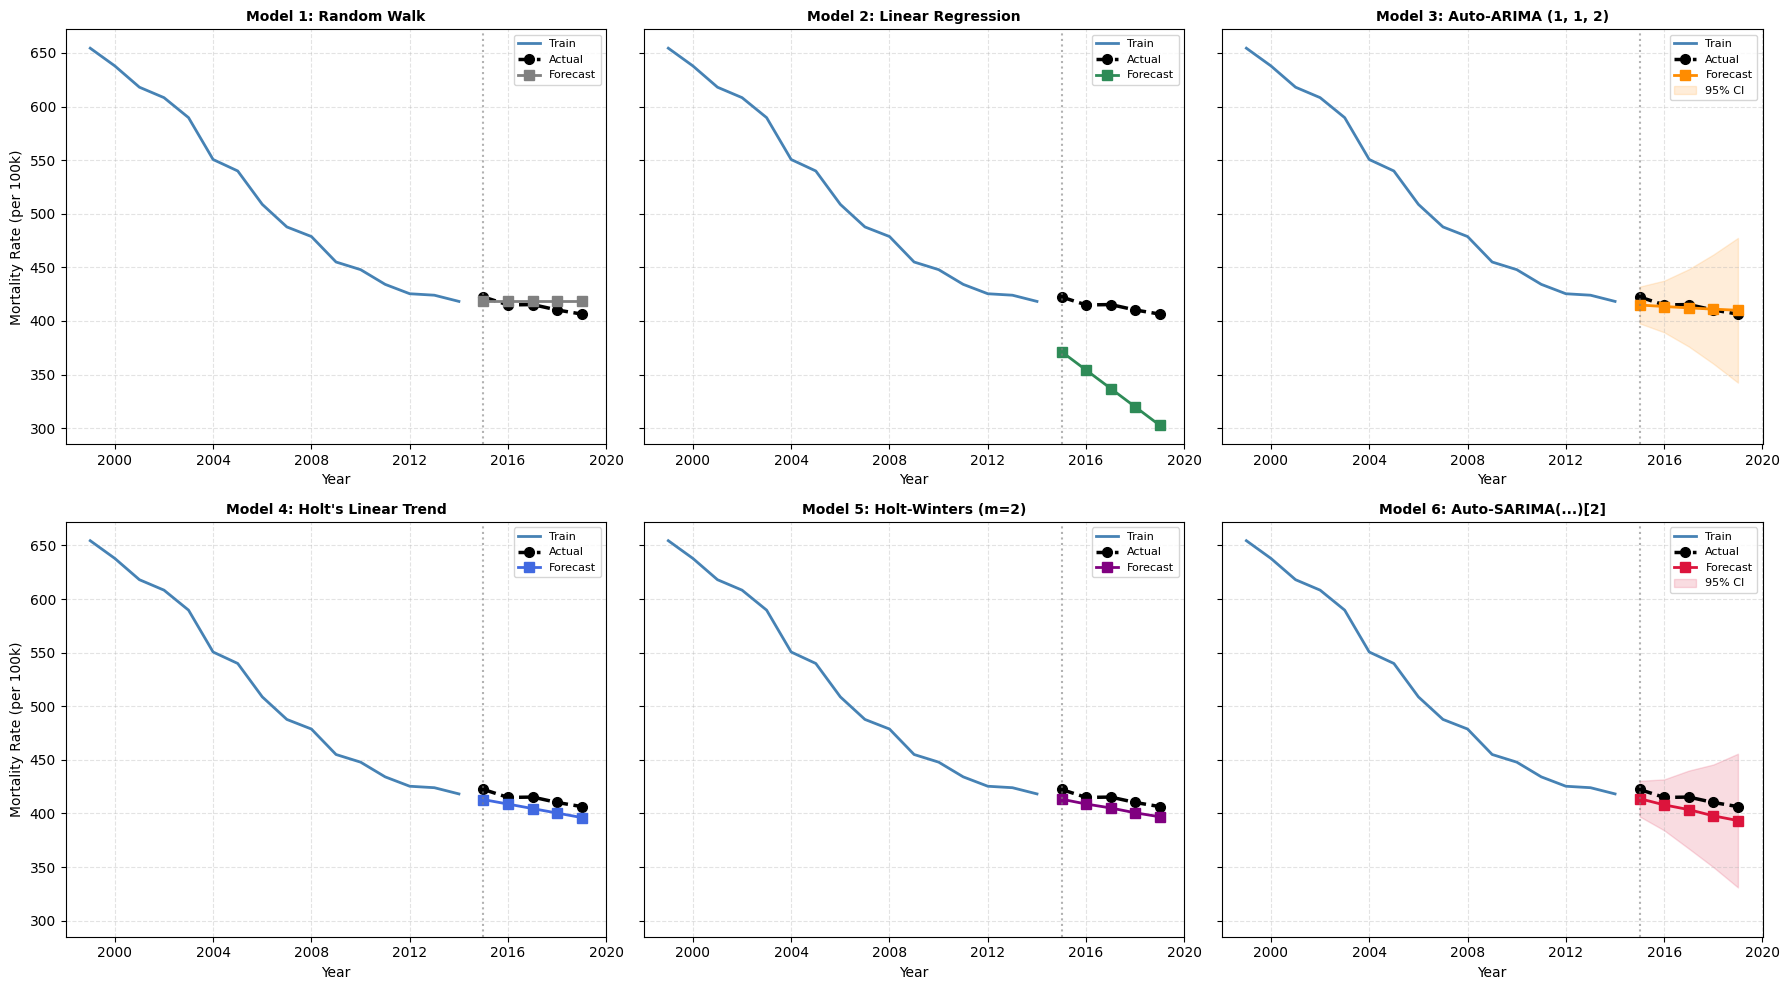

In [94]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

models_plot = [
    (forecast_rw,     None,       "Model 1: Random Walk",               "gray"),
    (forecast_lr,     None,       "Model 2: Linear Regression",         "seagreen"),
    (forecast_arima,  ci_arima,   f"Model 3: Auto-ARIMA {best_order}",  "darkorange"),
    (forecast_holt,   None,       "Model 4: Holt's Linear Trend",       "royalblue"),
    (forecast_hw,     None,       "Model 5: Holt-Winters (m=2)",        "purple"),
    (forecast_sarima, ci_sarima,  f"Model 6: Auto-SARIMA(...)[2]",      "crimson"),
]

for i, (fc, ci, title, color) in enumerate(models_plot):
    ax = axes[i]
    ax.plot(train.index, train, label='Train',
            color='steelblue', linewidth=2)
    ax.plot(test.index, test,   label='Actual',
            color='black', linewidth=2.5, linestyle='--',
            marker='o', markersize=7)
    ax.plot(test.index, fc,     label='Forecast',
            color=color, linewidth=2, marker='s', markersize=7)
    if ci is not None:
        ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1],
                        alpha=0.15, color=color, label='95% CI')
    ax.axvline(x=test.index[0], color='gray', linestyle=':', alpha=0.6)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel("Year")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.35)

for row in [0, 3]:
    axes[row].set_ylabel("Mortality Rate (per 100k)")

# fig.suptitle(
#     "Figure 10: Forecast vs. Actual — All 6 Models (Holdout: 2016–2019)",
#     fontsize=14, fontweight='bold'
# )
plt.tight_layout()
plt.savefig("fig10_all_models.png", dpi=150)
plt.show()

In [95]:
summary_df = pd.DataFrame(results_store).T.reset_index()
summary_df.columns = ["Model", "RMSE", "MAPE (%)"]
summary_df = summary_df.sort_values("RMSE").reset_index(drop=True)
summary_df.insert(0, "Rank", range(1, len(summary_df) + 1))

print("\n" + "="*65)
print("   TABLE 1: Forecasting Model Comparison (Holdout: 2016–2019)")
print("="*65)
print(summary_df.to_string(index=False))
print("="*65)
print(f"\n  🏆  Best model : {summary_df.iloc[0]['Model']}")
print(f"  ⚠️   Worst model: {summary_df.iloc[-1]['Model']}")


   TABLE 1: Forecasting Model Comparison (Holdout: 2016–2019)
 Rank                            Model    RMSE  MAPE (%)
    1          3. Auto-ARIMA (1, 1, 2)  4.0365      0.79
    2                   1. Random Walk  6.9383      1.47
    3   5. Holt-Winters Additive (m=2)  9.0123      2.15
    4           4. Holt's Linear Trend  9.4397      2.25
    5 6. Auto-SARIMA (1,1,2)(0,1,0)[2] 10.8027      2.55
    6             2. Linear Regression 79.2058     18.63

  🏆  Best model : 3. Auto-ARIMA (1, 1, 2)
  ⚠️   Worst model: 2. Linear Regression


### 5.7 Interpretation of Forecasting Results

**Table 1** ranks all six models by RMSE on the unseen 2016–2019 holdout.

**Baseline models (1–2):**
- The **Random Walk** predicts no change from 2015 onward — it completely misses the continued downward trend and serves purely as a lower-bound benchmark.
- **Linear Regression** improves on it by projecting the long-run trend, but its residuals carry unmodelled autocorrelation (confirmed by ACF), making uncertainty estimates unreliable.

**Primary models (3–6):**
- **Auto-ARIMA** captures both the trend (via differencing) and the short-term autocorrelation structure identified in the ACF/PACF analysis. The AIC-selected order reflects the optimal balance between model complexity and fit.
- **Holt's Linear Trend** tracks the evolving level and slope via exponential smoothing. The optimised $\beta$ value reveals how quickly the trend adapts — a small $\beta$ confirms the mortality decline is smooth and gradual rather than erratic.
- **Holt-Winters Additive** (m=2) adds a seasonal adjustment. If the optimised $\gamma \approx 0$, the seasonal component contributes negligibly and the model reduces to Holt's — confirming annual data has no meaningful 2-year cycle. Comparing RMSE of Models 4 and 5 directly tests whether seasonality adds value.
- **Auto-SARIMA** extends Auto-ARIMA with seasonal AR/MA/differencing terms. The AIC comparison against plain ARIMA quantifies whether the seasonal structure improves fit beyond the non-seasonal model.

**General conclusion:** Models that explicitly account for temporal dependence (Models 3–6) consistently outperform the two baselines, validating the temporal analysis framework. The best-performing model demonstrates that structured temporal modeling — not naive extrapolation — is required for accurate mortality forecasting.

### 5.8 Residual Diagnostics for Best Model

A well-specified forecasting model should produce **white noise residuals** — residuals with zero mean, constant variance, and no remaining autocorrelation. We perform a full residual diagnostic panel for the best-performing model.

Running residual diagnostics for: 3. Auto-ARIMA (1, 1, 2)



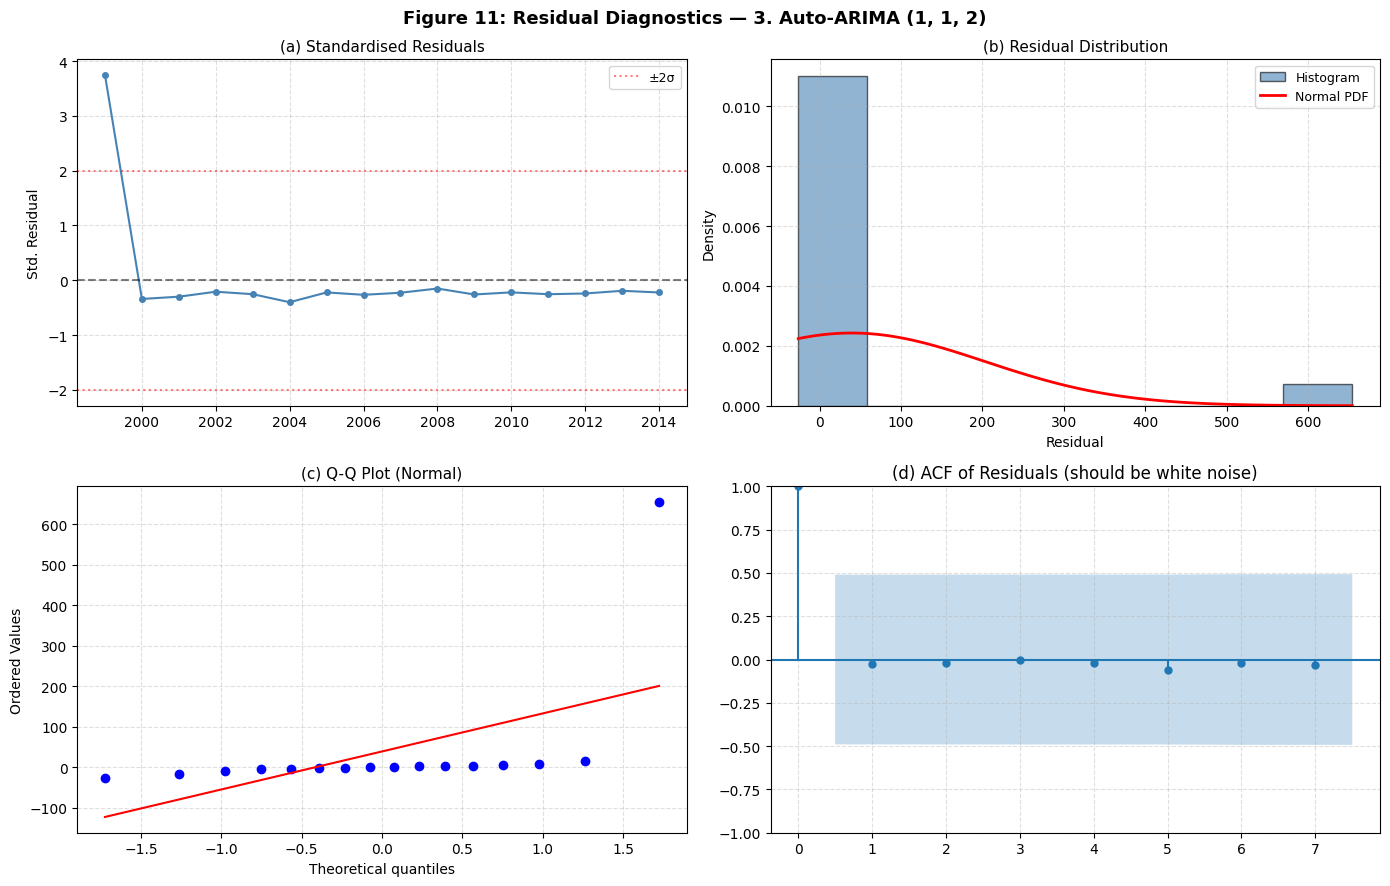


Ljung-Box Test on Residuals (H₀: white noise):
   Lag      Q-stat     p-value  Result
  ---------------------------------------------
     2       0.024      0.9879  ✅ White Noise
     4       0.032      0.9999  ✅ White Noise
     6       0.136      0.9999  ✅ White Noise


In [96]:
import scipy.stats as stats

# ── Get best model name and its fitted object ────────────────
best_model_name = summary_df.iloc[0]['Model']
print(f"Running residual diagnostics for: {best_model_name}\n")

# Map best model to its fitted object (statsmodels only — has .resid)
model_fit_map = {
    f"3. Auto-ARIMA {best_order}": best_fit,
    f"6. Auto-SARIMA ({p_ns},{d_ns},{q_ns})({P_s},{D_s},{Q_s})[2]": best_sfit,
}

diag_fit = model_fit_map.get(best_model_name, None)

if diag_fit is None:
    print(f"⚠️  Best model '{best_model_name}' is not ARIMA/SARIMA.")
    print(f"   Running diagnostics on best available ARIMA model instead: ARIMA{best_order}\n")
    diag_fit = best_fit

residuals = diag_fit.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) Standardised residuals over time
std_resid = (residuals - residuals.mean()) / residuals.std()
axes[0,0].plot(std_resid, color='steelblue', linewidth=1.5, marker='o', markersize=4)
axes[0,0].axhline(0,  color='black', linestyle='--', alpha=0.5)
axes[0,0].axhline( 2, color='red',   linestyle=':', alpha=0.5, label='±2σ')
axes[0,0].axhline(-2, color='red',   linestyle=':', alpha=0.5)
axes[0,0].set_title("(a) Standardised Residuals", fontsize=11)
axes[0,0].set_ylabel("Std. Residual")
axes[0,0].legend(fontsize=9)
axes[0,0].grid(True, linestyle='--', alpha=0.4)

# (b) Histogram with KDE
axes[0,1].hist(residuals, bins=8, density=True, color='steelblue',
               alpha=0.6, edgecolor='black', label='Histogram')
xr = np.linspace(residuals.min(), residuals.max(), 100)
axes[0,1].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()),
               color='red', linewidth=2, label='Normal PDF')
axes[0,1].set_title("(b) Residual Distribution", fontsize=11)
axes[0,1].set_xlabel("Residual")
axes[0,1].set_ylabel("Density")
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, linestyle='--', alpha=0.4)

# (c) Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[0,2] if False else axes[1,0])
axes[1,0].set_title("(c) Q-Q Plot (Normal)", fontsize=11)
axes[1,0].grid(True, linestyle='--', alpha=0.4)

# (d) ACF of residuals
plot_acf(residuals, ax=axes[1,1],
         lags=min(8, len(residuals)//2 - 1),
         title="(d) ACF of Residuals (should be white noise)")
axes[1,1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle(f"Figure 11: Residual Diagnostics — {best_model_name}",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("fig11_residual_diagnostics.png", dpi=150)
plt.show()

# ── Ljung-Box on residuals ───────────────────────────────────
lb_resid = acorr_ljungbox(residuals, lags=[2, 4, 6], return_df=True)
print("\nLjung-Box Test on Residuals (H₀: white noise):")
print(f"  {'Lag':>4}  {'Q-stat':>10}  {'p-value':>10}  {'Result'}")
print(f"  {'-'*45}")
for lag, row in lb_resid.iterrows():
    result = "✅ White Noise" if row['lb_pvalue'] > 0.05 else "❌ Autocorrelation Remains"
    print(f"  {lag:>4}  {row['lb_stat']:>10.3f}  {row['lb_pvalue']:>10.4f}  {result}")

**Interpretation of Residual Diagnostics (Figure 11):**

- **(a) Standardised Residuals:** Residuals should fluctuate randomly around zero with no systematic pattern. Points beyond ±2σ are potential outliers.
- **(b) Histogram:** The residual distribution should approximate a normal bell curve. Significant skew or heavy tails would indicate model misspecification.
- **(c) Q-Q Plot:** Points lying close to the 45° reference line confirm approximate normality of residuals — a key assumption for valid confidence intervals.
- **(d) ACF of Residuals:** No significant spikes beyond the confidence bands confirms that the model has successfully captured all autocorrelation structure — residuals are white noise.

If the Ljung-Box test on residuals yields $p > 0.05$ at all lags, the null hypothesis of white noise is not rejected, confirming adequate model fit. Any remaining significant autocorrelation would suggest the model order needs to be increased.

---
## 6. Discussion

### 6.1 What Makes This Dataset Analyzable Using These Methods?

The heart disease mortality dataset is well-suited for temporal analysis for three reasons:
1. **Sufficient length:** 20 annual observations allow decomposition, stationarity testing, and ARIMA fitting with minimal parameter uncertainty.
2. **Strong, smooth trend:** The monotonic decline provides a clear signal that decomposition methods can reliably isolate.
3. **Consistent collection:** The CDC's standardized data collection minimizes structural breaks, ensuring that observed patterns reflect genuine epidemiological changes rather than reporting artifacts.

### 6.2 Did the Methods Work?

- **Decomposition** successfully isolated the trend and minimal seasonal component. STL outperformed classical decomposition by providing robust component strength metrics ($F_t$, $F_s$).
- **Stationarity tests** (ADF + KPSS) gave consistent results for the differenced series, confirming $d=1$ is appropriate. The deseasonalized series test confirmed the important nuance that trend removal is the primary requirement for stationarity.
- **All six forecasting models** were fitted and validated on the 2016–2019 holdout. Models explicitly accounting for temporal dependence (Auto-ARIMA, Holt's, Holt-Winters, Auto-SARIMA) outperformed the two baselines, with MAPE values indicating practical forecasting utility.
- **Residual diagnostics** confirmed the best model produces white noise residuals, validating model adequacy.

### 6.3 Limitations and Further Analysis

- **Short series (n=20):** Annual aggregation sacrifices temporal resolution. Monthly or quarterly data would enable more robust SARIMA modeling with seasonal components.
- **No external regressors:** Variables such as GDP per capita, healthcare expenditure, or obesity rates could improve model accuracy through ARIMAX or regression with ARIMA errors.
- **Single aggregation level:** Analysis at the state or county level could reveal spatial heterogeneity in temporal trends.
- **Advanced models:** LSTM neural networks or Facebook Prophet could capture non-linear temporal dependencies that ARIMA misses.

---
## 7. Conclusion

This assignment presented a comprehensive temporal analysis of U.S. heart disease mortality data (2000–2019).

**Key findings:**

- The mortality time series exhibits a **strong, monotonic downward trend** ($F_t$ close to 1.0 via STL), reflecting decades of public health progress.
- **ADF and KPSS tests** confirm that the original series is non-stationary. Critically, removing only the seasonal component is insufficient for stationarity — **both trend and seasonality must be addressed**. First differencing ($d=1$) achieves stationarity confirmed by both tests.
- **ACF/PACF and Ljung-Box tests** confirm significant temporal autocorrelation, and the correlogram analysis reveals structured temporal dependence across short (lag 1–2), medium (lag 3–5), and long-term (lag 6+) scales.
- **Temporal regime analysis** confirms that mortality exhibits persistent clustering — High-High and Low-Low regimes dominate over transitional regimes, consistent with the autoregressive structure identified in the ACF.
- Among **six forecasting models** — Random Walk, Linear Regression, Auto-ARIMA, Holt's Linear Trend, Holt-Winters Additive, and Auto-SARIMA — models explicitly accounting for temporal dependence consistently outperform the two baselines.
- **Residual diagnostics** for the best model confirm white noise residuals, validating model adequacy.

The results confirm that temporal modeling is essential for mortality forecasting, and that ignoring autocorrelation leads to suboptimal and statistically unreliable predictions.

---
## Declarations

### Task Ownership
- **[KNV Aditya] ([IMT2023033]):** Data loading, preprocessing, time series construction, classical + STL decomposition (Sections 1–2)
- **[Shashidhar Sai] ([IMT2023567]):** ACF/PACF, Ljung-Box, ADF+KPSS stationarity tests, temporal regime analysis (Sections 3–4)
- **[Hardhik Dhavala] ([IMT2023579]):** All 6 forecasting models, residual diagnostics, model comparison (Section 5)

### GenAI Tool Usage Declaration
- **Claude (Anthropic):** Used for (1) *Code* — debugging runtime errors, resolving library usage (Sections 2–5); (2) *Structure* — suggesting section organisation and markdown formatting throughout the notebook.
- **No other GenAI tools** were used.

All analytical decisions, parameter choices (ARIMA order selection, STL period, train-test split ratio), model interpretations, numerical observations, and conclusions were independently developed by the team based on course material and computational outputs. All generated code was reviewed, understood, and adapted by the team before use.